In [12]:
import xarray as xr
import numpy as np
import scipy as sp
from scipy.optimize import least_squares
import statsmodels.api as sm

import matplotlib.pyplot as plt 
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from mpl_toolkits.axisartist.parasite_axes import HostAxes, ParasiteAxes
from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits import axisartist

def glb_avg(sst):
    #sst = sst.where((sst.lat-70)*(sst.lat+70)<0,drop=True)
    weight = np.cos(np.deg2rad(sst.lat))
    return (sst).weighted(weight).mean(('lat','lon'))

def spna_avg(var):
    return var.where((var.lat-45)*(var.lat-60)<=0,drop=True).where((var.lon-310)*(var.lat-340)<=0,drop=True).mean(dim=('lat','lon'))

def find_ols_params(x,y,cps):
    # find the ols parameters given the two change points 
    # cps: a list of change points
    xc1,xc2 = cps[:]
    x_temp = x[np.where((x>xc1)&(x<=xc2))[0]]
    y_temp = y[np.where((x>xc1)&(x<=xc2))[0]]
    mod=sm.OLS(y_temp,sm.add_constant(x_temp)).fit()
    b2 = mod.params[1] # slope of the second regime 
    y_xc1 = xc1*b2+mod.params[0] 
    y_xc2 = xc2*b2+mod.params[0] 
            
    x_temp1 = x[np.where(x<=xc1)[0]]-xc1
    y_temp1 = y[np.where(x<=xc1)[0]]-y_xc1
    def SSE(k,x=x_temp1,y=y_temp1):
        return np.sum((k*x-y)**2)
    b1 = least_squares(SSE,x0=np.array([0.2])).x[0]
    b0 = y_xc1-b1*xc1
            
    x_temp2 = x[np.where(x>xc2)[0]]-xc2
    y_temp2 = y[np.where(x>xc2)[0]]-y_xc2
    def SSE(k,x=x_temp2,y=y_temp2):
        return np.sum((k*x-y)**2)
    b3 = least_squares(SSE,x0=np.array([0.2])).x[0]
                        
    params = np.array([b0,b1,b2,b3,xc1,xc2])
    print(b1,b2,b3)
    return params

def ME2(y,y_fit):
    N = y.size
    return np.sqrt(np.sum((y-(a*x+b))**2)/(N-2))

def LinearFit(x,params):
    # linear fitting with two change points
    a,b1,b2,b3,xc1,xc2 = params
    y_pre = np.where(x<xc1,a+b1*x,a+b1*xc1+b2*(x-xc1))
    return np.where(x>=xc2,a+b1*xc1+b2*(xc2-xc1)+b3*(x-xc2),y_pre)

def smooth(var,twindow=15):
    temp = var.rolling(year=twindow,center=True).mean('year')
    return temp.where(temp.isnull()==False,drop=True)

fdir = '../../data/'
pic_dir = '../../output/figures/'

In [2]:
amoc={}
for exp in ['LE','SF-GHG','SF-AAER','SF-xAER','SF-EE','SF-BMB']:
    print(exp)
    amoc[exp] = xr.open_mfdataset(fdir+'CESM2_clean_dataset/AMOCI/CESM2-'+exp+'_AMOC40_ts_*.nc',combine='by_coords')['AMOC'].load()

spna_data = {} 
gm_data = {}
whi_data = {}
amoc_new = [] # a list to store all the AMOC index points

for exp in ['SF-GHG','SF-BMB','SF-EE']:
    spna_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_SPNASSTA_combined.txt').reshape((15,8,201))
    gm_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_GMSSTA_combined.txt').reshape((15,8,201)) #rlzn,term,year
    
for exp in ['SF-AAER']:
    spna_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_SPNASSTA_combined.txt').reshape((20,8,201))[:,:,:]
    gm_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_GMSSTA_combined.txt').reshape((20,8,201))[:,:,:] #rlzn,term,year
    
for exp in ['LE']:
    spna_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_SPNASSTA_combined.txt').reshape((100,8,251))
    gm_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_GMSSTA_combined.txt').reshape((100,8,251)) #rlzn,term,year

exp='SF-xAER'
spna_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_SPNASSTA_combined.txt').reshape((10,8,131))
gm_data[exp] = np.loadtxt(fdir+'PTC_out/CESM2-'+exp+'_decomposed_GMSSTA_combined.txt').reshape((10,8,131)) #rlzn,term,year

for exp in ['LE','SF-GHG','SF-BMB','SF-EE','SF-AAER','SF-xAER']:
    whi_data[exp] = spna_data[exp]-gm_data[exp]
    amoc_new.extend((amoc[exp]).values.flatten().tolist())

LE
SF-GHG
SF-AAER
SF-xAER
SF-EE
SF-BMB


In [9]:
H2O_data = {}
low_cld_data = {}
high_cld_data = {}
med_cld_data = {}

OHTC_data = {}

for exp in ['LE','SF-GHG','SF-AAER','SF-BMB','SF-EE']: #
    H2O_data[exp] = xr.open_dataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_SPNA_minus_GM_H2O_SRF.nc')['H2O_SRF']/1e-3 # unit: 1e-3 mol/mol
    low_cld_data[exp] = (xr.open_dataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_CLDLOW_SPNA.nc')['CLDLOW'])
    high_cld_data[exp] = (xr.open_dataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_CLDHGH_SPNA.nc')['CLDHGH'])
    med_cld_data[exp] = (xr.open_dataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_CLDMED_SPNA.nc')['CLDMED'])
    
    NHT45 = (xr.open_mfdataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_N_HEAT_*45.nc',combine='by_coords')['N_HEAT'])
    NHT60 = (xr.open_mfdataset(fdir+'CESM2_clean_dataset/CESM2-'+exp+'_N_HEAT_*60.nc',combine='by_coords')['N_HEAT'])
    OHTC_data[exp] = NHT45-NHT60
    print(exp, H2O_data[exp].shape,low_cld_data[exp].shape, OHTC_data[exp].shape, amoc[exp].shape)

LE (100, 251) (100, 251) (100, 251) (100, 251)
SF-GHG (15, 201) (15, 201) (15, 201) (15, 201)
SF-AAER (20, 201) (20, 201) (20, 201) (20, 201)
SF-BMB (15, 201) (15, 201) (15, 201) (15, 201)
SF-EE (15, 201) (15, 201) (15, 201) (15, 201)


In [10]:
## AMOC Bins 
xc1,xc2 = 11.5, 20
amoc_bins = np.arange(7,33,2) # center value of bins 
def plot_bins(x,y,ax,bins=amoc_bins, bin_w=1):
    for i in range(len(bins)):
        data = y[np.where((x<bins[i]+1)&(x>=bins[i]-1))[0]]
        ax.boxplot(data,positions=[bins[i]],showmeans=True,meanline=True,
                   whis=(5, 95),showfliers=False,widths=1, patch_artist=True,
                   meanprops={"color": "salmon", "linewidth": 2,"linestyle":'solid'},
                   medianprops={"color": "royalblue", "linewidth": 2},
                   boxprops={"facecolor": "skyblue", "linewidth": 0.5},
                   whiskerprops={"color": "k", "linewidth": 0.5},
                   capprops={"color": "k", "linewidth": 0.5})
interval = 1  # scatter interval 

0.04144696170650751 -0.061516861105005045 0.02007296822403326
0.07767770265770571 0.23918711200511658 0.02196140008827918
-0.0018692227498156959 0.14507681468715336 0.0130544494251725
0.01973763347517739 0.013787298482305485 0.021609182509139197
0.17183837890625003 0.28981943098567714 0.04036695207434696
0.0010802739729889872 -0.003726514248942942 -0.0010034055459200658


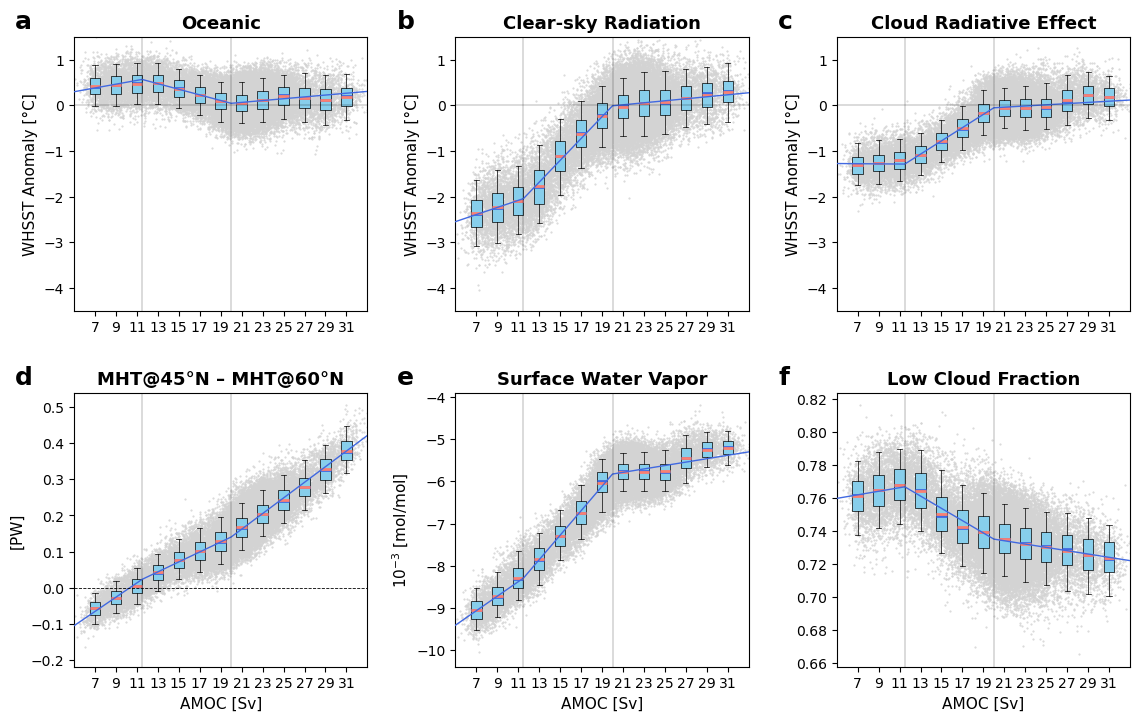

In [14]:
fig, axs = plt.subplots(2, 3, figsize=(12, 9))
plt.subplots_adjust(top=0.85,bottom=0.15,left=0.07,right=0.95,hspace=0.3,wspace=0.3)
titles = ['Oceanic','Clear-sky Radiation','Cloud Radiative Effect']
order = 'abc' 

ptc_sum = []
ptc_ocn = []
ptc_clr = []
ptc_crf = []
X = whi_data
for exp in ['LE','SF-GHG','SF-BMB','SF-EE','SF-AAER','SF-xAER']:
    temp = np.sum(X[exp][:,:-1,:],axis=1).flatten()
    ptc_sum.extend(temp.tolist())

    temp = np.sum(X[exp][:,5:7,:],axis=1).flatten()
    ptc_ocn.extend(temp.tolist())

    temp = np.sum(X[exp][:,1:3,:],axis=1).flatten()
    ptc_crf.extend(temp.tolist())   
        
    temp = np.sum(X[exp][:,3:5,:],axis=1).flatten()
    ptc_clr.extend(temp.tolist())   
    
axs[0,0].scatter(np.array(amoc_new)[::interval],np.array(ptc_ocn)[::interval],c='lightgrey',marker='.',s=1)
plot_bins(np.array(amoc_new),np.array(ptc_ocn),axs[0,0])
axs[0,1].scatter(np.array(amoc_new)[::interval],np.array(ptc_clr)[::interval],c='lightgrey',marker='.',s=1)
plot_bins(np.array(amoc_new),np.array(ptc_clr),axs[0,1])
axs[0,2].scatter(np.array(amoc_new)[::interval],np.array(ptc_crf)[::interval],c='lightgrey',marker='.',s=1)
plot_bins(np.array(amoc_new),np.array(ptc_crf),axs[0,2])
    
x2fit = np.array(amoc_new)
y2fit = [np.array(ptc_ocn),np.array(ptc_clr),np.array(ptc_crf)]
xin = np.arange(1,35.1,0.1)
for i in range(3):
    axs[0,i].plot(xin,LinearFit(xin,find_ols_params(x2fit,y2fit[i],[xc1,xc2])),lw=1,c='royalblue',label='LinearFit',zorder=7)
    axs[0,i].axhline(y=0,c='k',ls='-',lw=0.2,zorder=7)
    axs[0,i].axvline(x=xc1,c='k',ls='-',lw=0.2,zorder=7)
    axs[0,i].axvline(x=xc2,c='k',ls='-',lw=0.2,zorder=7)
    axs[0,i].set_title(titles[i],loc='center',fontdict={'weight': 'bold','size': 13})
    axs[0,i].set_title(order[i],loc='left',fontdict={'weight': 'bold', 'size': 18},x=-0.2)
    axs[0,i].set_xlim(5,33)
    axs[0,i].set_ylim(-4.5,1.5)
    axs[0,i].set_ylabel('WHSST Anomaly [\u00B0C]',fontsize=11)

    
titles = ['MHT@45\u00B0N – MHT@60\u00B0N','Surface Water Vapor','Low Cloud Fraction']
order = 'def'

ohtc_all = []
h2o_all = []
lc_all = []
amoc_new2 = []

for exp in ['LE','SF-GHG','SF-AAER','SF-BMB','SF-EE']:
    ohtc_all.extend(OHTC_data[exp].values.flatten().tolist())
    amoc_new2.extend((amoc[exp]).values.flatten().tolist())
    h2o_all.extend(H2O_data[exp].values.flatten().tolist())
    lc_all.extend(low_cld_data[exp].values.flatten().tolist())
    
data2plot = [ohtc_all, h2o_all, lc_all]
xin = np.arange(1,35.1,0.1)
for i in range(3):
    axs[1,i].scatter(np.array(amoc_new2)[::interval],
                   np.array(data2plot[i])[::interval], c='lightgrey',marker='.',s=1)
    plot_bins(np.array(amoc_new2), np.array(data2plot[i]),axs[1,i])
    
    x2fit = np.array(amoc_new2)
    y2fit = np.array(data2plot[i]) 
    
    axs[1,i].plot(xin,LinearFit(xin,find_ols_params(x2fit,y2fit,[xc1,xc2])),lw=1,c='royalblue',label='LinearFit',zorder=7)
    axs[1,i].axvline(x=xc1,c='k',ls='-',lw=0.2,zorder=7)
    axs[1,i].axvline(x=xc2,c='k',ls='-',lw=0.2,zorder=7)
    axs[1,i].set_xlabel('AMOC [Sv]',fontsize=11)
    axs[1,i].set_title(titles[i],loc='center',fontdict={'weight': 'bold','size': 13})
    axs[1,i].set_title(order[i],loc='left',fontdict={'weight': 'bold', 'size': 18},x=-0.2)
    axs[1,i].set_xlim(5,33)

axs[1,0].set_ylabel('[PW]',fontsize=11)
axs[1,1].set_ylabel('10$^{-3}$ [mol/mol]',fontsize=11)
axs[1,0].axhline(y=0,c='k',ls='--',lw=0.6,zorder=7)

plt.savefig(pic_dir+'F2_WHSST_budget_anomaly_decomposed_physics.pdf')
plt.show()